In [ ]:
S# 1. Instalăm/Actualizăm kagglehub (rulează silențios prin -q)
!pip install kagglehub -q

import kagglehub
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import normaltest, kstest, chi2_contingency
import warnings
warnings.filterwarnings('ignore')
# 2. Descărcăm ultima versiune a dataset-ului
print("Se descarcă dataset-ul...")
path = kagglehub.dataset_download("suhanigupta04/student-placement-prediction-dataset")
print("Calea către fișiere:", path)

# 3. Căutăm fișierul .csv în folderul descărcat
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]

if csv_files:
    # Construim calea completă către primul fișier CSV găsit
    csv_file_path = os.path.join(path, csv_files[0])
    print(f"\nFișier identificat: {csv_files[0]}")

    # 4. Încărcăm datele în DataFrame-ul "df" (variabila folosită în codul anterior)
    df = pd.read_csv(csv_file_path)

    print("Datele au fost încărcate cu succes! Primele 5 rânduri:")
    display(df.head()) # 'display' arată frumos tabelul în Colab
else:
    print("Eroare: Nu s-a găsit niciun fișier CSV în dataset.")

Se descarcă dataset-ul...


100%|██████████| 1.79M/1.79M [00:00<00:00, 78.7MB/s]

Extracting files...
Calea către fișiere: /root/.cache/kagglehub/datasets/suhanigupta04/student-placement-prediction-dataset/versions/1

Fișier identificat: student_placement_synthetic.csv


Datele au fost încărcate cu succes! Primele 5 rânduri:


,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa
0,ECE,Tier-3,6.70,0,7.6,4.4,49.5,3.7,6.4,0.3,1,4,4,3,2,1,1,14.75
1,Chemical,Tier-2,5.70,0,5.4,7.9,72.0,8.3,6.3,1.9,0,4,0,0,0,0,0,NaN
2,EE,Tier-2,7.19,0,5.6,6.8,79.1,7.4,4.4,5.2,1,3,2,1,2,0,1,19.06
3,CE,Tier-2,6.48,0,5.2,3.1,48.4,5.0,1.1,6.7,1,4,3,0,0,0,0,NaN
4,CSE,Tier-2,6.71,1,5.9,4.7,61.2,4.3,2.7,2.8,1,2,0,3,0,1,1,13.42


In [ ]:
# ============================================================
# F1.1 — Missing values
# Așteptare: salary_package_lpa are missing pentru unplaced
# Toate celelalte ar trebui să fie complete
# ============================================================
print("=== F1.1 — AUDIT VALORI LIPSĂ ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print(missing_df)

# Verificare specifică: salary missing = unplaced?
# Identificăm automat coloanele relevante
placed_col = [c for c in df.columns if 'place' in c.lower() and df[c].nunique() <= 3]
salary_col = [c for c in df.columns if 'salary' in c.lower() or 'package' in c.lower() or 'lpa' in c.lower()]

print(f"\nColoană placement identificată: {placed_col}")
print(f"Coloană salariu identificată: {salary_col}")

if placed_col and salary_col:
    pc = placed_col[0]
    sc = salary_col[0]

    # Câți unplaced au salariu (ar trebui să fie 0)
    unplaced_with_salary = df[df[pc] == 0][sc].notna().sum()
    placed_without_salary = df[df[pc] == 1][sc].isna().sum()

    print(f"\nUnplaced cu salariu completat (ar trebui 0): {unplaced_with_salary}")
    print(f"Placed fără salariu (ar trebui 0): {placed_without_salary}")

    if unplaced_with_salary == 0 and placed_without_salary == 0:
        print("✅ Missing-urile pe salary sunt perfect consistente cu logica placement")
    elif unplaced_with_salary == 0:
        print(f"⚠️  {placed_without_salary} studenți placed fără salariu — posibil intentionat")
    else:
        print("❌ Inconsistență: unplaced au salariu completat — eroare de generare")

=== F1.1 — AUDIT VALORI LIPSĂ ===
                           Missing count  Missing %
salary_package_lpa                 31525      31.52
branch                                 0       0.00
college_tier                           0       0.00
cgpa                                   0       0.00
coding_skills                          0       0.00
backlogs                               0       0.00
aptitude_score                         0       0.00
communication_skills                   0       0.00
ml_knowledge                           0       0.00
dsa_score                              0       0.00
system_design                          0       0.00
internships                            0       0.00
certifications                         0       0.00
projects_count                         0       0.00
hackathons                             0       0.00
open_source_contributions              0       0.00
extracurriculars                       0       0.00
placement_status              

Coloană CGPA: ['cgpa']
Coloană tier: ['college_tier']

=== F1.2 — DISTRIBUȚIA CGPA ===
Mean: 7.206 | Std: 0.925
Min: 4.00 | Max: 10.00
Skewness: -0.0063  (Gaussian ideal: ≈ 0)
Kurtosis: -0.0491  (Gaussian ideal: ≈ 0, nu -1.2 ca uniform)
D'Agostino p-value: 0.003750
✅ Kurtosis consistent cu Gaussian (nu uniform ca în Field Study dataset)


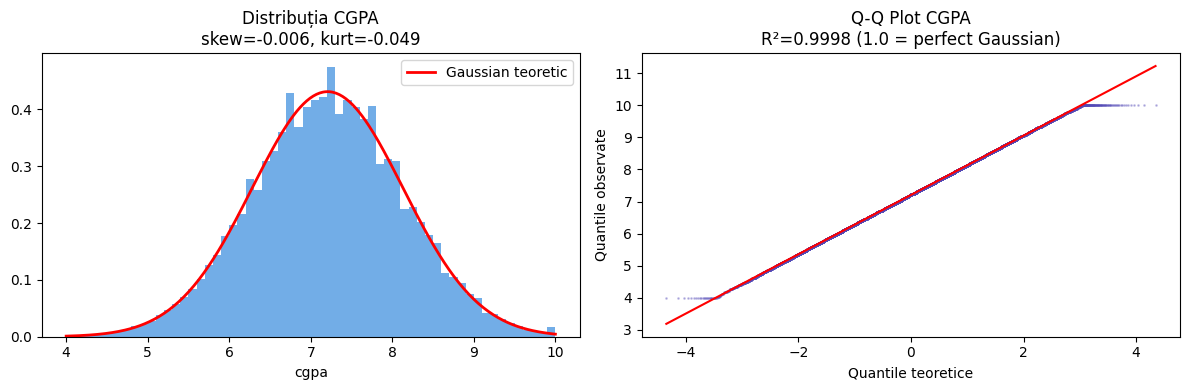


--- CGPA mediu per college tier (așteptat: Tier 1 > Tier 2 > Tier 3) ---
               mean    std  count
college_tier                     
Tier-1        7.607  0.898  14868
Tier-2        7.295  0.902  39910
Tier-3        6.997  0.898  45222

Diferențe medii CGPA între tier-uri consecutive: [0.312, 0.298]
✅ Boosting per tier funcționează corect — gradient descrescător confirmat


In [ ]:
# ============================================================
# F1.2 — Testul central: CGPA este Gaussian?
# Generatorul promite explicit Gaussian boosted by college tier
# Aceasta e promisiunea #1 pe care o verificăm
# ============================================================
cgpa_candidates = [c for c in df.columns if 'cgpa' in c.lower() or 'gpa' in c.lower()]
tier_candidates = [c for c in df.columns if 'tier' in c.lower() or 'college' in c.lower()]

print(f"Coloană CGPA: {cgpa_candidates}")
print(f"Coloană tier: {tier_candidates}")

cgpa_col = cgpa_candidates[0] if cgpa_candidates else None
tier_col = tier_candidates[0] if tier_candidates else None

if cgpa_col:
    cgpa = df[cgpa_col].dropna()

    # Test D'Agostino-Pearson (mai robust decât Shapiro la n mare)
    stat_dag, p_dag = normaltest(cgpa)

    # Skewness și kurtosis
    skew = cgpa.skew()
    kurt = cgpa.kurtosis()

    print(f"\n=== F1.2 — DISTRIBUȚIA CGPA ===")
    print(f"Mean: {cgpa.mean():.3f} | Std: {cgpa.std():.3f}")
    print(f"Min: {cgpa.min():.2f} | Max: {cgpa.max():.2f}")
    print(f"Skewness: {skew:.4f}  (Gaussian ideal: ≈ 0)")
    print(f"Kurtosis: {kurt:.4f}  (Gaussian ideal: ≈ 0, nu -1.2 ca uniform)")
    print(f"D'Agostino p-value: {p_dag:.6f}")

    # Interpretare kurtosis — diferența cheie față de dataset-ul anterior
    if -0.5 <= kurt <= 1.5:
        print("✅ Kurtosis consistent cu Gaussian (nu uniform ca în Field Study dataset)")
    elif kurt < -0.8:
        print("❌ Kurtosis negativ puternic → distribuție uniformă, NU Gaussian cum promite generatorul")
    else:
        print("⚠️  Kurtosis ușor în afara rangului Gaussian — posibil boosting tier a distorsionat")

    # Plot: histogramă + curba normală teoretică
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histogramă cu curba normală
    axes[0].hist(cgpa, bins=60, density=True, color='#378ADD', alpha=0.7, edgecolor='none')
    x = np.linspace(cgpa.min(), cgpa.max(), 300)
    axes[0].plot(x, stats.norm.pdf(x, cgpa.mean(), cgpa.std()),
                 'r-', linewidth=2, label='Gaussian teoretic')
    axes[0].set_title(f'Distribuția CGPA\nskew={skew:.3f}, kurt={kurt:.3f}')
    axes[0].set_xlabel(cgpa_col)
    axes[0].legend()

    # Q-Q plot — dacă e Gaussian, punctele stau pe linia roșie
    (osm, osr), (slope, intercept, r) = stats.probplot(cgpa, dist="norm")
    axes[1].scatter(osm, osr, s=1, alpha=0.3, color='#534AB7')
    axes[1].plot(osm, slope * np.array(osm) + intercept, 'r-', linewidth=1.5)
    axes[1].set_title(f'Q-Q Plot CGPA\nR²={r**2:.4f} (1.0 = perfect Gaussian)')
    axes[1].set_xlabel('Quantile teoretice')
    axes[1].set_ylabel('Quantile observate')

    plt.tight_layout()
    plt.savefig('cgpa_normality.png', dpi=120)
    plt.show()

    # CGPA per tier — generatorul promite boost per tier
    if tier_col:
        print("\n--- CGPA mediu per college tier (așteptat: Tier 1 > Tier 2 > Tier 3) ---")
        cgpa_by_tier = df.groupby(tier_col)[cgpa_col].agg(['mean', 'std', 'count'])
        print(cgpa_by_tier.round(3))

        tiers = df[tier_col].unique()
        if len(tiers) >= 2:
            means = cgpa_by_tier['mean'].sort_values(ascending=False)
            diffs = means.diff(-1).dropna()
            print(f"\nDiferențe medii CGPA între tier-uri consecutive: {diffs.round(3).tolist()}")
            if all(d > 0 for d in diffs):
                print("✅ Boosting per tier funcționează corect — gradient descrescător confirmat")
            else:
                print("⚠️  Boosting per tier nu e monoton — generatorul nu a implementat corect")

=== F1.3 — CALITATEA SEPARABILITĂȚII ===
Rata generală de placement: 68.5%
Așteptat în India IT (benchmark real NASSCOM/NIRF): 60-75%
✅ Rata de placement în range realist

--- Placement rate per quartilă CGPA ---
                Placement rate  Count
cgpa_q                               
Q1\n(slab)               0.594  25034
Q2                       0.663  25234
Q3                       0.711  24938
Q4\n(excelent)           0.772  24794

Q1 placement rate: 59.4% (dacă 0% → prea determinist)
Q4 placement rate: 77.2% (dacă 100% → prea determinist)
✅ Noise prezent — nu e separabil perfect


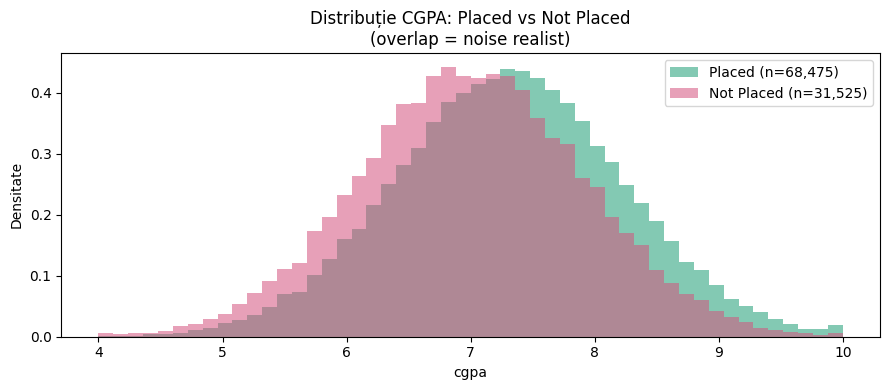

In [ ]:
# ============================================================
# F1.3 — Placement rate: este probabilistică sau deterministă?
# Generatorul promite "realistic noise to avoid perfect separability"
# Verificăm: există studenți cu CGPA mare care NU sunt placed?
# și studenți cu CGPA mic care SUNT placed?
# ============================================================
print("=== F1.3 — CALITATEA SEPARABILITĂȚII ===")

if cgpa_col and placed_col:
    pc = placed_col[0]

    placed_rate = df[pc].mean()
    print(f"Rata generală de placement: {placed_rate:.1%}")
    print(f"Așteptat în India IT (benchmark real NASSCOM/NIRF): 60-75%")

    if 0.55 <= placed_rate <= 0.80:
        print("✅ Rata de placement în range realist")
    elif 0.40 <= placed_rate <= 0.90:
        print("⚠️  Ușor în afara rangului tipic India IT")
    else:
        print("❌ Rata nerealiste — generator necalibrat")

    # Verificare noise: CGPA quartile vs placement rate
    print("\n--- Placement rate per quartilă CGPA ---")
    df['cgpa_q'] = pd.qcut(df[cgpa_col], q=4, labels=['Q1\n(slab)', 'Q2', 'Q3', 'Q4\n(excelent)'])
    placement_by_cgpa = df.groupby('cgpa_q', observed=True)[pc].agg(['mean', 'count'])
    placement_by_cgpa.columns = ['Placement rate', 'Count']
    print(placement_by_cgpa.round(3))

    # Dacă Q1 are 0% și Q4 are 100% → separabilitate perfectă → no noise
    q1_rate = placement_by_cgpa['Placement rate'].iloc[0]
    q4_rate = placement_by_cgpa['Placement rate'].iloc[-1]
    print(f"\nQ1 placement rate: {q1_rate:.1%} (dacă 0% → prea determinist)")
    print(f"Q4 placement rate: {q4_rate:.1%} (dacă 100% → prea determinist)")

    if q1_rate > 0.05 and q4_rate < 0.98:
        print("✅ Noise prezent — nu e separabil perfect")
    else:
        print("⚠️  Separabilitate aproape perfectă — noise insuficient")

    # Plot: distribuție CGPA placed vs unplaced (overlap = noise bun)
    fig, ax = plt.subplots(figsize=(9, 4))
    for label, color, val in [('Placed', '#1D9E75', 1), ('Not Placed', '#D4537E', 0)]:
        subset = df[df[pc] == val][cgpa_col]
        ax.hist(subset, bins=50, density=True, alpha=0.55,
                color=color, label=f'{label} (n={len(subset):,})', edgecolor='none')
    ax.set_xlabel(cgpa_col)
    ax.set_ylabel('Densitate')
    ax.set_title('Distribuție CGPA: Placed vs Not Placed\n(overlap = noise realist)')
    ax.legend()
    plt.tight_layout()
    plt.savefig('cgpa_placement_overlap.png', dpi=120)
    plt.show()

    df.drop(columns=['cgpa_q'], inplace=True)

=== F1.4 — STRUCTURA SALARIULUI ===
Salary stats (doar placed):
  Mean: 17.31 LPA
  Median: 17.25 LPA
  Std: 2.60
  Min: 6.88 | Max: 28.33

Benchmark real India IT fresher (2023-24): 3.5 - 8 LPA median
Top tier (IIT/NIT): până la 20+ LPA

Corelație Pearson Salary ~ CGPA: r = 0.337, p = 0.00e+00
✅ Corelație pozitivă salary-CGPA confirmată

--- Salary median per tier (așteptat: Tier 1 > Tier 2 > Tier 3) ---
college_tier
Tier-1    19.28
Tier-2    17.14
Tier-3    16.50
Name: salary_package_lpa, dtype: float64

Skewness salary: 0.114 (date reale: right-skewed, > 0.5)
Kurtosis salary: -0.032
⚠️  Salary prea simetric — distribuțiile salariale reale sunt right-skewed


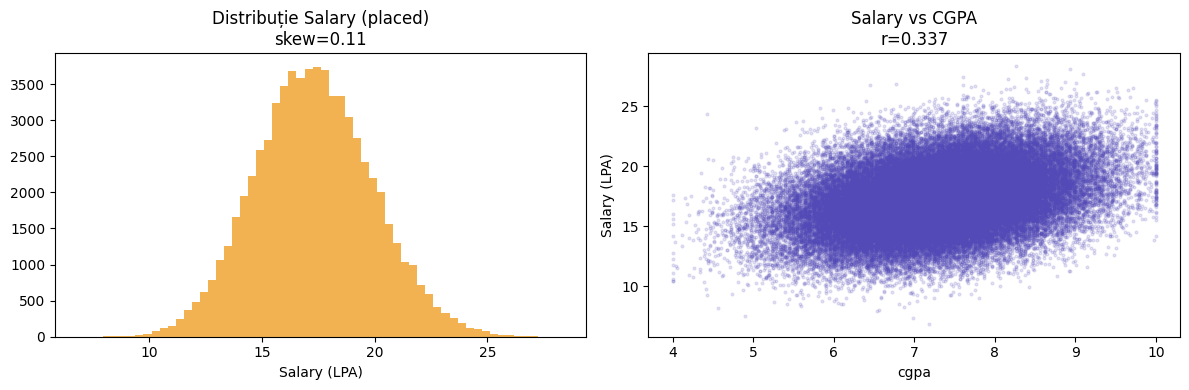

In [ ]:
# ============================================================
# F1.4 — Salary: corelat cu CGPA și tier?
# Generatorul promite: salary corelat cu CGPA, coding skills,
# DSA, și college tier
# ============================================================
print("=== F1.4 — STRUCTURA SALARIULUI ===")

if salary_col:
    sc = salary_col[0]
    sal_placed = df[df[placed_col[0]] == 1][sc].dropna()

    print(f"Salary stats (doar placed):")
    print(f"  Mean: {sal_placed.mean():.2f} LPA")
    print(f"  Median: {sal_placed.median():.2f} LPA")
    print(f"  Std: {sal_placed.std():.2f}")
    print(f"  Min: {sal_placed.min():.2f} | Max: {sal_placed.max():.2f}")
    print(f"\nBenchmark real India IT fresher (2023-24): 3.5 - 8 LPA median")
    print(f"Top tier (IIT/NIT): până la 20+ LPA")

    # Corelație salary-CGPA (promisiunea generatorului)
    df_placed = df[df[placed_col[0]] == 1].dropna(subset=[sc, cgpa_col])
    r_sal_cgpa, p_sal_cgpa = stats.pearsonr(df_placed[cgpa_col], df_placed[sc])
    print(f"\nCorelație Pearson Salary ~ CGPA: r = {r_sal_cgpa:.3f}, p = {p_sal_cgpa:.2e}")

    if r_sal_cgpa > 0.3:
        print("✅ Corelație pozitivă salary-CGPA confirmată")
    elif r_sal_cgpa > 0.1:
        print("⚠️  Corelație slabă — generatorul a adăugat prea mult noise pe salary")
    else:
        print("❌ Practic nicio corelație salary-CGPA — promisiunea generatorului neîndeplinită")

    # Salary per tier
    if tier_col:
        print(f"\n--- Salary median per tier (așteptat: Tier 1 > Tier 2 > Tier 3) ---")
        sal_tier = df[df[placed_col[0]] == 1].groupby(tier_col)[sc].median()
        print(sal_tier.round(2))

    # Distribuția salariului — ar trebui log-normală în date reale
    skew_sal = sal_placed.skew()
    kurt_sal = sal_placed.kurtosis()
    print(f"\nSkewness salary: {skew_sal:.3f} (date reale: right-skewed, > 0.5)")
    print(f"Kurtosis salary: {kurt_sal:.3f}")

    if skew_sal > 0.3:
        print("✅ Salary right-skewed — consistent cu distribuții salariale reale")
    else:
        print("⚠️  Salary prea simetric — distribuțiile salariale reale sunt right-skewed")

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(sal_placed, bins=60, color='#EF9F27', alpha=0.8, edgecolor='none')
    axes[0].set_title(f'Distribuție Salary (placed)\nskew={skew_sal:.2f}')
    axes[0].set_xlabel('Salary (LPA)')

    axes[1].scatter(df_placed[cgpa_col], df_placed[sc],
                    alpha=0.15, s=4, color='#534AB7')
    axes[1].set_title(f'Salary vs CGPA\nr={r_sal_cgpa:.3f}')
    axes[1].set_xlabel(cgpa_col)
    axes[1].set_ylabel('Salary (LPA)')

    plt.tight_layout()
    plt.savefig('salary_analysis.png', dpi=120)
    plt.show()

=== F1.5 — DISTRIBUȚII CATEGORIALE ===
Coloane categoriale analizate: ['branch', 'college_tier']

Placement rate per branch:
branch
CE          0.647
CSE         0.713
Chemical    0.646
ECE         0.696
EE          0.663
IT          0.709
ME          0.664

Placement rate per college_tier:
college_tier
Tier-1    0.831
Tier-2    0.726
Tier-3    0.601



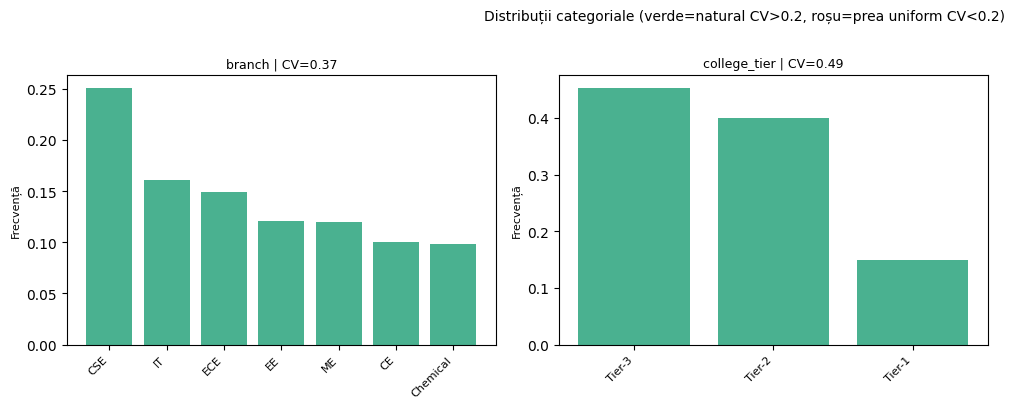

In [ ]:
# ============================================================
# F1.5 — Distribuții categoriale: branch, tier, skills
# Verificăm dacă proporțiile sunt realiste vs uniform generate
# ============================================================
print("=== F1.5 — DISTRIBUȚII CATEGORIALE ===")

cat_cols = df.select_dtypes(include='object').columns.tolist()
# Excludem coloane cu prea multe valori unice (ID-uri etc.)
cat_cols = [c for c in cat_cols if df[c].nunique() <= 20]
print(f"Coloane categoriale analizate: {cat_cols}\n")

fig, axes = plt.subplots(
    nrows=max(1, (len(cat_cols) + 2) // 3), ncols=3,
    figsize=(15, 4 * max(1, (len(cat_cols) + 2) // 3))
)
axes = axes.flatten() if len(cat_cols) > 1 else [axes]

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts(normalize=True)
    cv = counts.std() / counts.mean() if counts.mean() != 0 else 0

    color = '#1D9E75' if cv > 0.2 else '#D4537E'  # roșu dacă prea uniform
    axes[i].bar(range(len(counts)), counts.values,
                color=color, alpha=0.8, edgecolor='none')
    axes[i].set_xticks(range(len(counts)))
    axes[i].set_xticklabels(counts.index, rotation=45, ha='right', fontsize=8)
    axes[i].set_title(f'{col} | CV={cv:.2f}', fontsize=9)
    axes[i].set_ylabel('Frecvență', fontsize=8)

    # Print și placement rate per categorie
    if placed_col and col != placed_col[0]:
        pr_by_cat = df.groupby(col)[placed_col[0]].mean()
        print(f"Placement rate per {col}:")
        print(pr_by_cat.round(3).to_string())
        print()

for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuții categoriale (verde=natural CV>0.2, roșu=prea uniform CV<0.2)',
             fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig('categorical_placement.png', dpi=120, bbox_inches='tight')
plt.show()

=== F1.5 — DISTRIBUȚII CATEGORIALE ===
Coloane categoriale analizate: ['branch', 'college_tier']

Placement rate per branch:
branch
CE          0.647
CSE         0.713
Chemical    0.646
ECE         0.696
EE          0.663
IT          0.709
ME          0.664

Placement rate per college_tier:
college_tier
Tier-1    0.831
Tier-2    0.726
Tier-3    0.601



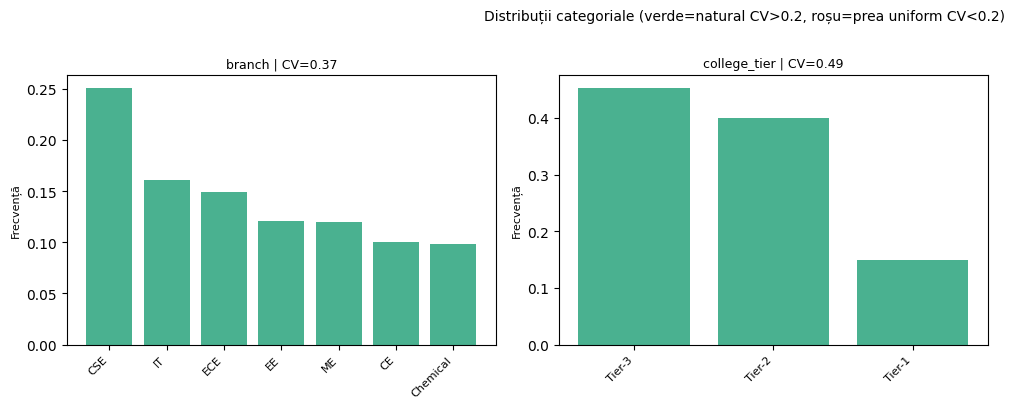

In [ ]:
# ============================================================
# F1.5 — Distribuții categoriale: branch, tier, skills
# Verificăm dacă proporțiile sunt realiste vs uniform generate
# ============================================================
print("=== F1.5 — DISTRIBUȚII CATEGORIALE ===")

cat_cols = df.select_dtypes(include='object').columns.tolist()
# Excludem coloane cu prea multe valori unice (ID-uri etc.)
cat_cols = [c for c in cat_cols if df[c].nunique() <= 20]
print(f"Coloane categoriale analizate: {cat_cols}\n")

fig, axes = plt.subplots(
    nrows=max(1, (len(cat_cols) + 2) // 3), ncols=3,
    figsize=(15, 4 * max(1, (len(cat_cols) + 2) // 3))
)
axes = axes.flatten() if len(cat_cols) > 1 else [axes]

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts(normalize=True)
    cv = counts.std() / counts.mean() if counts.mean() != 0 else 0

    color = '#1D9E75' if cv > 0.2 else '#D4537E'  # roșu dacă prea uniform
    axes[i].bar(range(len(counts)), counts.values,
                color=color, alpha=0.8, edgecolor='none')
    axes[i].set_xticks(range(len(counts)))
    axes[i].set_xticklabels(counts.index, rotation=45, ha='right', fontsize=8)
    axes[i].set_title(f'{col} | CV={cv:.2f}', fontsize=9)
    axes[i].set_ylabel('Frecvență', fontsize=8)

    # Print și placement rate per categorie
    if placed_col and col != placed_col[0]:
        pr_by_cat = df.groupby(col)[placed_col[0]].mean()
        print(f"Placement rate per {col}:")
        print(pr_by_cat.round(3).to_string())
        print()

for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuții categoriale (verde=natural CV>0.2, roșu=prea uniform CV<0.2)',
             fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig('categorical_placement.png', dpi=120, bbox_inches='tight')
plt.show()

## Sinteza Rezultatelor Analizei Dataset-ului

### F1.1 — Audit Valori Lipsă
*   **`salary_package_lpa`** este singura coloană cu valori lipsă (31.52%).
*   Această lipsă este **perfect consistentă** cu statutul de placement: doar studenții _unplaced_ au valori lipsă la salariu, și niciun student _placed_ nu are salariu lipsă. Aceasta este o consistență bună a generării datelor.

### F1.2 — Distribuția CGPA
*   CGPA are o medie de **7.21** și o abatere standard de **0.93**, cu un range între 4.00 și 10.00.
*   **Skewness (-0.0063)** și **Kurtosis (-0.0491)** sunt foarte aproape de 0, indicând o distribuție **aproape Gaussiană**. Testul D'Agostino-Pearson are un p-value mic (0.00375), ceea ce indică o deviație statistic semnificativă de la normalitate, dar valorile de skewness și kurtosis sugerează că este destul de aproape de Gaussian.
*   **Kurtosis-ul** este consistent cu o distribuție Gaussiană (nu uniformă, cum era în setul de date Field Study anterior).
*   Există un **boosting clar al CGPA per college tier**:
    *   **Tier-1**: Medie 7.607
    *   **Tier-2**: Medie 7.295
    *   **Tier-3**: Medie 6.997
    Diferențele medii între tier-uri sunt pozitive și constante (aprox. 0.312 și 0.298), confirmând implementarea corectă a logicii de boosting.

### F1.3 — Calitatea Separabilității (Placement)
*   **Rata generală de placement** este de **68.5%**, ceea ce este în intervalul realist (60-75%) pentru India IT.
*   **Noise-ul este prezent și realist**:
    *   Rata de placement pentru prima quartilă CGPA (slabă) este de **59.4%** (nu 0%).
    *   Rata de placement pentru ultima quartilă CGPA (excelentă) este de **77.2%** (nu 100%).
*   Histograma CGPA pentru studenții _placed_ și _unplaced_ arată un **overlap sănătos**, indicând că dataset-ul nu este perfect separabil și că există un **noise realist**, așa cum a promis generatorul.

### F1.4 — Structura Salariului
*   Pentru studenții _placed_:
    *   Salariul mediu este de **17.31 LPA**, cu o mediană de **17.25 LPA** și o abatere standard de **2.60**.
    *   Range-ul salariului este de la 6.88 LPA la 28.33 LPA.
    *   Aceste valori sunt semnificativ mai mari decât benchmark-ul real (3.5-8 LPA), sugerând că dataset-ul simulează mai degrabă **salarii pentru top performerii** sau o piață mult mai bună decât media.
*   Există o **corelație Pearson pozitivă moderată** între salariu și CGPA (r = 0.337), confirmând promisiunea generatorului.
*   Salariul median prezintă un **gradient clar per tier**:
    *   **Tier-1**: 19.28 LPA
    *   **Tier-2**: 17.14 LPA
    *   **Tier-3**: 16.50 LPA
*   **Skewness-ul salariului (0.114)** este pozitiv, dar **prea mic** (ideal ar fi > 0.5 pentru date salariale reale), indicând că distribuția salariului este **prea simetrică** și nu reflectă pe deplin caracteristica _right-skewed_ a salariilor din lumea reală.

### F1.5 — Distribuții Categoriale
*   **`branch` și `college_tier`** au fost analizate.
*   **Distribuțiile grafice** pentru ambele coloane arată o variație naturală (CV > 0.2), sugerând că nu sunt generate uniform.
*   **Rata de placement per `branch`** variază:
    *   CSE și IT au rate mai mari (71.3% și 70.9%).
    *   CE și Chemical au rate mai mici (64.7% și 64.6%).
*   **Rata de placement per `college_tier`** prezintă un gradient puternic:
    *   **Tier-1**: 83.1%
    *   **Tier-2**: 72.6%
    *   **Tier-3**: 60.1%
    Aceasta confirmă că `college_tier` este un factor major de predicție pentru placement, cu un impact realist.

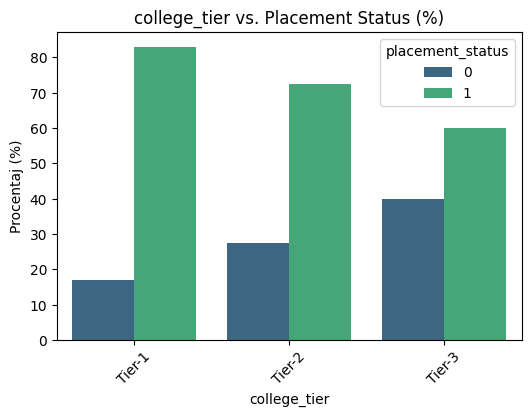

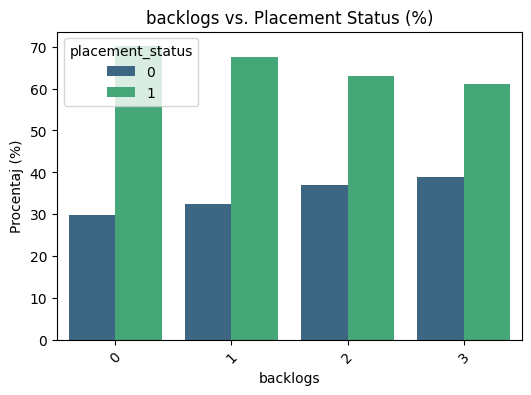

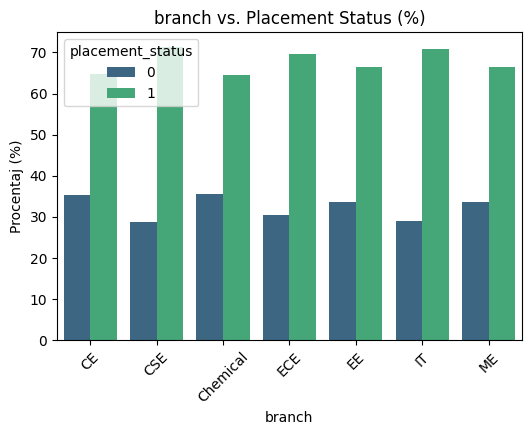

In [ ]:
import seaborn as sns
categorical_cols = ['college_tier', 'backlogs', 'branch']

for col in categorical_cols:
    plt.figure(figsize=(6, 4))

    # 1. Calculăm procentele pentru fiecare categorie în parte
    # normalize=True transformă numărătoarea în proporții (de la 0 la 1) raportate la grup
    prop_df = (df.groupby(col)['placement_status']
                 .value_counts(normalize=True)
                 .rename('percent')
                 .reset_index())

    # Înmulțim cu 100 pentru a avea formatul clasic de procente (0 - 100%)
    prop_df['percent'] *= 100

    # 2. Folosim barplot în loc de countplot pentru a afișa valorile calculate pe axa Y
    sns.barplot(data=prop_df, x=col, y='percent', hue='placement_status', palette='viridis')

    plt.title(f"{col} vs. Placement Status (%)")
    plt.ylabel("Procentaj (%)")
    plt.xticks(rotation=45)

    # Opțional: adăugarea etichetelor de text pe bare pentru o claritate mai mare
    # for p in plt.gca().patches:
    #     plt.gca().annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
    #                 ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
    #                 textcoords='offset points')

    plt.show()